In [1]:
# ======================================
# 📦 1. Import Libraries
# ======================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import LabelEncoder

In [2]:
# ======================================
# 📂 2. Load Dataset
# ======================================
df = pd.read_csv("laptopData.csv")

# نظرة سريعة على البيانات
print("Shape before cleaning:", df.shape)
print(df.info())
print(df.isnull().sum())

Shape before cleaning: (1303, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB
None
Unnamed: 0          30
Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram

In [7]:
df = pd.read_csv("laptopData.csv")

# نظرة أولى
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


,Unnamed: 0,Price
count,1273.000000,1273.000000
mean,652.674784,59955.814073
std,376.493027,37332.251005
min,0.000000,9270.720000
25%,327.000000,31914.720000
50%,652.000000,52161.120000
75%,980.000000,79333.387200
max,1302.000000,324954.720000


In [4]:
df.isnull().sum()


Unnamed: 0          30
Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64

In [5]:
df[df.isnull().any(axis=1)]
# عرض الصفوف التي تحتوي على قيم مفقودة

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.isnull().sum().sum()
# عدّ القيم المفقودة في كامل البيانات

np.int64(360)

In [9]:
# ====================================== 
# 🧹 3. Data Cleaning (تنظيف البيانات)
# ======================================

# حذف العمود الغير مهم Unnamed: 0 لو موجود
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# --------------------------------------
# 🔸 تنظيف الأعمدة الرقمية (زي Ram و Weight و Inches)
# --------------------------------------

# تنظيف عمود RAM (إزالة GB وتحويله إلى int)
if 'Ram' in df.columns:
    df['Ram'] = df['Ram'].astype(str).str.replace('GB', '', regex=False).str.strip()
    df['Ram'] = df['Ram'].replace(['?', 'N/A', 'na', 'NaN', '-', '_', ''], np.nan)
    df['Ram'] = df['Ram'].astype(float)

# تنظيف عمود Weight
if 'Weight' in df.columns:
    df['Weight'] = df['Weight'].astype(str).str.replace('kg', '', regex=False).str.strip()
    df['Weight'] = df['Weight'].replace(['?', 'N/A', 'na', 'NaN', '-', '_', ''], np.nan)
    df['Weight'] = df['Weight'].astype(float)

# تنظيف عمود Inches
if 'Inches' in df.columns:
    df['Inches'] = df['Inches'].replace(['?', 'N/A', 'na', 'NaN', '-', '_', ''], np.nan)
    df['Inches'] = df['Inches'].astype(float)

In [10]:
df.isnull().sum()

Company             0
TypeName            0
Inches              1
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              1
Price               0
dtype: int64

In [11]:
# --------------------------------------
# 🔹 تنظيف الأعمدة النصية من الرموز والقيم الغريبة
# --------------------------------------
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].replace(['?', 'N/A', 'na', 'NaN', '-', '_', ''], np.nan)
    df[col] = df[col].str.strip()

In [12]:
# --------------------------------------
# 🔍 التأكد من وجود NaN قبل المعالجة
# --------------------------------------
print("\n🔍 Missing values before filling:")
print(df.isnull().sum())


🔍 Missing values before filling:
Company             0
TypeName            0
Inches              1
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              1
Gpu                 0
OpSys               0
Weight              1
Price               0
dtype: int64


In [13]:
# --------------------------------------
# 🔧 معالجة القيم المفقودة
# --------------------------------------

# 1️⃣ نملأ القيم المفقودة في الأعمدة الرقمية بمتوسط العمود
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    mean_val = df[col].mean()
    df[col].fillna(mean_val, inplace=True)

# 2️⃣ نملأ الأعمدة النصية بأكثر قيمة تكرارًا (mode)
for col in df.select_dtypes(include=['object']).columns:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_17160\3794842772.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mean_val, inplace=True)
C:\Users\ahmed\AppData\Local\Temp\ipykernel_17160\3794842772.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, whe

In [14]:
# --------------------------------------
# ✅ التحقق النهائي من عدم وجود أي NaN
# --------------------------------------
print("\n✅ Missing values after cleaning:")
print(df.isnull().sum())

print("\n🎯 DataFrame is now fully clean and ready for Categorical Data step!\n")
df.info()


✅ Missing values after cleaning:
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

🎯 DataFrame is now fully clean and ready for Categorical Data step!

<class 'pandas.core.frame.DataFrame'>
Index: 1273 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1273 non-null   object 
 1   TypeName          1273 non-null   object 
 2   Inches            1273 non-null   float64
 3   ScreenResolution  1273 non-null   object 
 4   Cpu               1273 non-null   object 
 5   Ram               1273 non-null   float64
 6   Memory            1273 non-null   object 
 7   Gpu               1273 non-null   object 
 8   OpSys             1273 non-null   object 
 9   Weight           

In [15]:
from sklearn.preprocessing import LabelEncoder

# ======================================
# 🎛️ 4. Categorical Data Encoding
# ======================================

# إنشاء نسخة من الداتا
df_encoded = df.copy()

# الأعمدة النصية
categorical_cols = df_encoded.select_dtypes(include=['object']).columns

# نطبع الأعمدة الفئوية
print("🧩 Categorical columns:")
print(categorical_cols)

# نعمل LabelEncoder
le = LabelEncoder()

# نطبق التحويل على كل عمود فئوي
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# عرض أول صفوف بعد التحويل
print("\n✅ After Label Encoding:")
print(df_encoded.head())

# التأكد من أن كل الأعمدة بقت أرقام
print("\n📊 Data types after encoding:")
print(df_encoded.dtypes)


🧩 Categorical columns:
Index(['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Memory', 'Gpu',
       'OpSys'],
      dtype='object')

✅ After Label Encoding:
   Company  TypeName  Inches  ScreenResolution  Cpu   Ram  Memory  Gpu  OpSys  \
0        1         4    13.3                23   65   8.0       4   56      8   
1        1         4    13.3                 1   63   8.0       2   50      8   
2        7         3    15.6                 8   74   8.0      16   52      4   
3        1         4    15.4                25   85  16.0      29    8      8   
4        1         4    13.3                23   67   8.0      16   57      8   

   Weight        Price  
0    1.37   71378.6832  
1    1.34   47895.5232  
2    1.86   30636.0000  
3    1.83  135195.3360  
4    1.37   96095.8080  

📊 Data types after encoding:
Company               int64
TypeName              int64
Inches              float64
ScreenResolution      int64
Cpu                   int64
Ram                 float64
Memo

In [16]:
# -----------------------------
# 1️⃣ معالجة عمود Cpu
# -----------------------------
# مثال: 'Intel Core i7 7700HQ' -> نطلع منها 'Intel'
df['CpuBrand'] = df['Cpu'].apply(lambda x: x.split()[0])

In [18]:
# -----------------------------
# 2️⃣ معالجة عمود Gpu
# -----------------------------
# مثال: 'Nvidia GeForce GTX 1050' -> نطلع منها 'Nvidia'
df['GpuBrand'] = df['Gpu'].apply(lambda x: x.split()[0])

In [19]:
# -----------------------------
# 3️⃣ معالجة عمود ScreenResolution
# -----------------------------
# استخراج هل الجهاز Touchscreen ولا لأ
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)

# استخراج دقة الشاشة (Full HD, 4K, ... إلخ)
def get_resolution_category(x):
    x = x.lower()
    if '4k' in x:
        return '4K'
    elif 'full hd' in x:
        return 'Full HD'
    elif 'hd' in x:
        return 'HD'
    else:
        return 'Other'

df['ResolutionType'] = df['ScreenResolution'].apply(get_resolution_category)

In [23]:
# -----------------------------
# 4️⃣ معالجة عمود Memory
# -----------------------------
# أمثلة:
# '512GB SSD' -> SSD = 512
# '1TB HDD + 256GB SSD' -> HDD = 1000, SSD = 256

import re

def clean_memory(x):
    # إزالة المسافات الزايدة
    x = str(x).strip()

    # استبدال وحدات السعة
    x = x.replace('TB', '000')  # 1TB = 1000GB
    x = x.replace('GB', '')

    # إزالة أي نقاط داخل الأرقام (مثلاً 1.0 -> 1)
    x = re.sub(r'(\d+)\.\d+', r'\1', x)
    return x

df['Memory'] = df['Memory'].apply(clean_memory)

def extract_memory_type(x, mem_type):
    total = 0
    parts = str(x).split('+')
    for part in parts:
        if mem_type in part:
            # نستخدم regex لاستخراج أول رقم في النص
            match = re.search(r'\d+', part)
            if match:
                total += int(match.group(0))
    return total

df['SSD'] = df['Memory'].apply(lambda x: extract_memory_type(x, 'SSD'))
df['HDD'] = df['Memory'].apply(lambda x: extract_memory_type(x, 'HDD'))
df['FlashStorage'] = df['Memory'].apply(lambda x: extract_memory_type(x, 'Flash'))

# عرض أول 10 صفوف علشان تتأكد إن البيانات طلعت صح
print(df[['Memory', 'SSD', 'HDD', 'FlashStorage']].head(10))

              Memory  SSD  HDD  FlashStorage
0            128 SSD  128    0             0
1  128 Flash Storage    0    0           128
2            256 SSD  256    0             0
3            512 SSD  512    0             0
4            256 SSD  256    0             0
5            500 HDD    0  500             0
6  256 Flash Storage    0    0           256
7  256 Flash Storage    0    0           256
8            512 SSD  512    0             0
9            256 SSD  256    0             0


In [25]:
# -----------------------------
# 5️⃣ التأكد من أن عمود Ram رقمي
# -----------------------------
# بعض البيانات قد تكون نصية أو رقمية حسب المصدر
# لذلك نضمن أنه رقم باستخدام astype(int)
df['Ram'] = df['Ram'].astype(int)


In [27]:
# -----------------------------
# 6️⃣ تحويل عمود Weight من نص إلى رقم
# -----------------------------
# أولاً: تحويل كل القيم إلى نص لتجنب الخطأ
# ثانيًا: إزالة كلمة "kg"
# ثالثًا: تحويل الناتج إلى رقم مع تجاهل الأخطاء
df['Weight'] = (
    df['Weight']
    .astype(str)                # نحول الكل لنص أولاً
    .str.replace('kg', '', regex=False)  # نزيل "kg"
    .replace('?', np.nan)       # نستبدل القيم الغريبة بـ NaN
    .astype(float)              # نحول إلى float
)
# عرض أول 5 صفوف للتأكد
print(df['Weight'].head())

0    1.37
1    1.34
2    1.86
3    1.83
4    1.37
Name: Weight, dtype: float64


In [28]:
# -----------------------------
# 7️⃣ التأكد من الأعمدة الجديدة
# -----------------------------
print(df[['CpuBrand', 'GpuBrand', 'Touchscreen', 'ResolutionType', 'SSD', 'HDD', 'Ram', 'Weight']].head())

  CpuBrand GpuBrand  Touchscreen ResolutionType  SSD  HDD  Ram  Weight
0    Intel    Intel            0          Other  128    0    8    1.37
1    Intel    Intel            0          Other    0    0    8    1.34
2    Intel    Intel            0        Full HD  256    0    8    1.86
3    Intel      AMD            0          Other  512    0   16    1.83
4    Intel    Intel            0          Other  256    0    8    1.37


In [29]:
# ================================
# 🧩 5️⃣ معالجة عمود OpSys
# ================================
# مثال: "Windows 10", "macOS", "Linux", "No OS", "Chrome OS"

def simplify_os(x):
    x = x.lower()
    if 'windows' in x:
        return 'Windows'
    elif 'mac' in x:
        return 'Mac'
    elif 'linux' in x:
        return 'Linux'
    elif 'chrome' in x:
        return 'Chrome OS'
    else:
        return 'Other'

df['OpSys'] = df['OpSys'].apply(simplify_os)

In [30]:
# ================================
# 🧩 6️⃣ حذف الأعمدة القديمة الغير مفيدة بعد الفصل
# ================================
df.drop(columns=['ScreenResolution', 'Cpu', 'Gpu'], inplace=True)

In [31]:
# ================================
# 🧩 7️⃣ التشفير (Label Encoding)
# ================================
le = LabelEncoder()
for col in ['Company', 'TypeName', 'CpuBrand', 'GpuBrand', 'OpSys']:
    df[col] = le.fit_transform(df[col])

In [32]:
# ================================
# 🧩 8️⃣ النتيجة النهائية
# ================================
print("\n✅ بعد المعالجة:")
print(df.head())
print("\n📊 معلومات الأعمدة بعد التنظيف:")
print(df.info())


✅ بعد المعالجة:
   Company  TypeName  Inches  Ram             Memory  OpSys  Weight  \
0        1         4    13.3    8            128 SSD      2    1.37   
1        1         4    13.3    8  128 Flash Storage      2    1.34   
2        7         3    15.6    8            256 SSD      3    1.86   
3        1         4    15.4   16            512 SSD      2    1.83   
4        1         4    13.3    8            256 SSD      2    1.37   

         Price  CpuBrand  GpuBrand  Touchscreen ResolutionType  SSD  HDD  \
0   71378.6832         1         2            0          Other  128    0   
1   47895.5232         1         2            0          Other    0    0   
2   30636.0000         1         2            0        Full HD  256    0   
3  135195.3360         1         0            0          Other  512    0   
4   96095.8080         1         2            0          Other  256    0   

   FlashStorage  
0             0  
1           128  
2             0  
3             0  
4        

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['ResolutionType'] = le.fit_transform(df['ResolutionType'])

# حذف العمود الأصلي Memory لأنه خلاص استُخدم
df.drop(columns=['Memory'], inplace=True)

print("✅ Final columns ready for modeling:")
print(df.dtypes)


✅ Final columns ready for modeling:
Company             int64
TypeName            int64
Inches            float64
Ram                 int64
OpSys               int64
Weight            float64
Price             float64
CpuBrand            int64
GpuBrand            int64
Touchscreen         int64
ResolutionType      int64
SSD                 int64
HDD                 int64
FlashStorage        int64
dtype: object


In [34]:
from sklearn.model_selection import train_test_split

# المدخلات (features) والمخرجات (target)
X = df.drop(columns=['Price'])
y = df['Price']

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Training data shape:", X_train.shape)
print("✅ Testing data shape:", X_test.shape)


✅ Training data shape: (1018, 13)
✅ Testing data shape: (255, 13)


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("📊 Model Performance:")
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


📊 Model Performance:
R² Score: 0.5994058532126101
MAE: 17390.1399978986
RMSE: 24106.70938224667


In [36]:
# ===========================================
# ⚙️ Final Feature Preparation + First Model
# ===========================================

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [37]:
# -----------------------------
# 1️⃣ تحويل ResolutionType إلى أرقام
# -----------------------------
le = LabelEncoder()
df['ResolutionType'] = le.fit_transform(df['ResolutionType'])

# حذف العمود Memory لأنه خلاص اتحلل إلى SSD / HDD / FlashStorage
if 'Memory' in df.columns:
    df.drop(columns=['Memory'], inplace=True)

print("✅ بعد تجهيز الأعمدة:")
print(df.dtypes)
print("\n📏 شكل الداتا النهائي:", df.shape)

✅ بعد تجهيز الأعمدة:
Company             int64
TypeName            int64
Inches            float64
Ram                 int64
OpSys               int64
Weight            float64
Price             float64
CpuBrand            int64
GpuBrand            int64
Touchscreen         int64
ResolutionType      int64
SSD                 int64
HDD                 int64
FlashStorage        int64
dtype: object

📏 شكل الداتا النهائي: (1273, 14)


In [38]:
# -----------------------------
# 2️⃣ تقسيم البيانات إلى train/test
# -----------------------------
X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n✅ Training shape:", X_train.shape)
print("✅ Testing shape:", X_test.shape)


✅ Training shape: (1018, 13)
✅ Testing shape: (255, 13)


In [39]:
# -----------------------------
# 3️⃣ تجربة أول موديل بسيط (Linear Regression)
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [40]:
# -----------------------------
# 4️⃣ تقييم الموديل
# -----------------------------
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n📊 Model Performance:")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


📊 Model Performance:
R² Score: 0.5994
MAE: 17390.14
RMSE: 24106.71


In [41]:
# -----------------------------
# 5️⃣ اختبار سريع على أول 5 قيم
# -----------------------------
comparison = pd.DataFrame({
    "Actual": y_test[:5].values,
    "Predicted": y_pred[:5]
})
print("\n🔍 مقارنة سريعة بين القيم الفعلية والمتوقعة:")
print(comparison)


🔍 مقارنة سريعة بين القيم الفعلية والمتوقعة:
     Actual     Predicted
0  53226.72  66567.518744
1  58554.72  63923.893465
2  30476.16  78518.249605
3  24455.52  35313.347892
4  28185.12  27171.079430


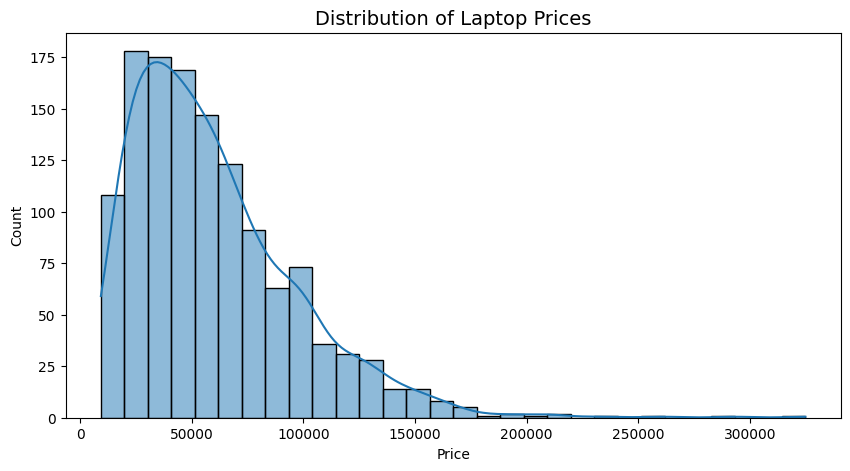

In [43]:
# 📊 EDA (Exploratory Data Analysis)

import matplotlib.pyplot as plt
import seaborn as sns

# =====================================
# 🔍 1️⃣ نظرة عامة على التوزيعات
# =====================================
plt.figure(figsize=(10,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Distribution of Laptop Prices", fontsize=14)
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

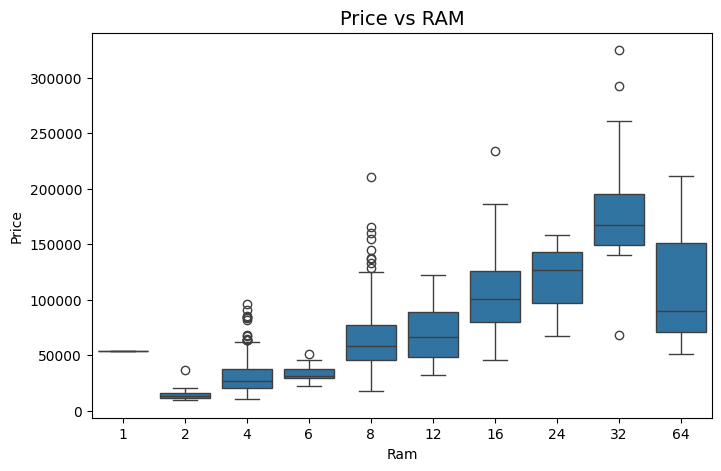

In [44]:
# =====================================
# 🔍 2️⃣ علاقة السعر بالـ RAM
# =====================================
plt.figure(figsize=(8,5))
sns.boxplot(x='Ram', y='Price', data=df)
plt.title("Price vs RAM", fontsize=14)
plt.show()

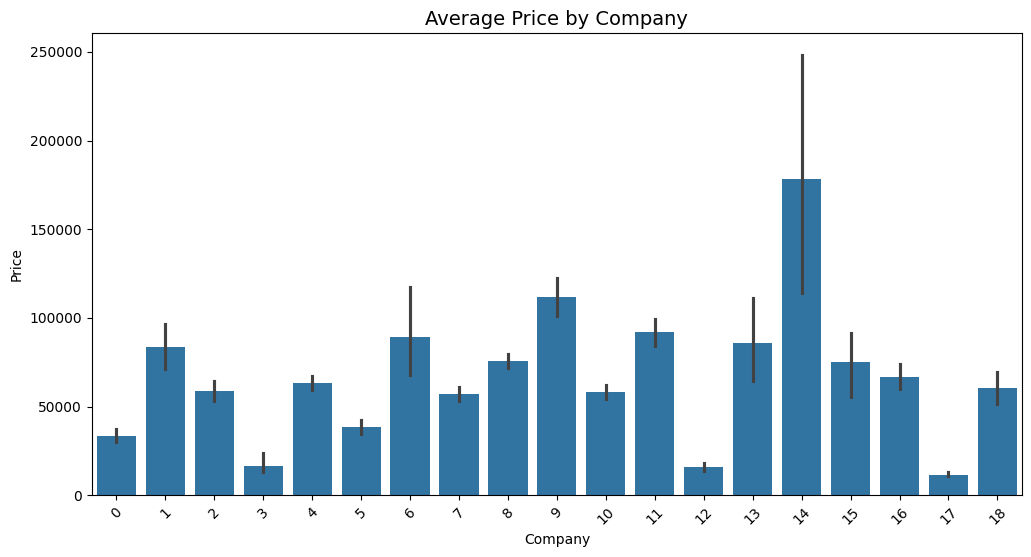

In [45]:
# =====================================
# 🔍 3️⃣ علاقة السعر بالـ Company
# =====================================
plt.figure(figsize=(12,6))
sns.barplot(x='Company', y='Price', data=df)
plt.title("Average Price by Company", fontsize=14)
plt.xticks(rotation=45)
plt.show()

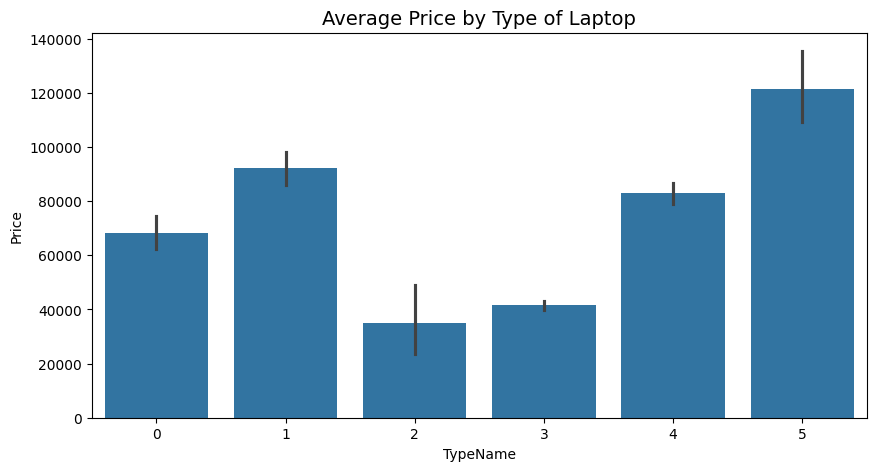

In [46]:
# =====================================
# 🔍 4️⃣ علاقة السعر بالـ TypeName
# =====================================
plt.figure(figsize=(10,5))
sns.barplot(x='TypeName', y='Price', data=df)
plt.title("Average Price by Type of Laptop", fontsize=14)
plt.show()

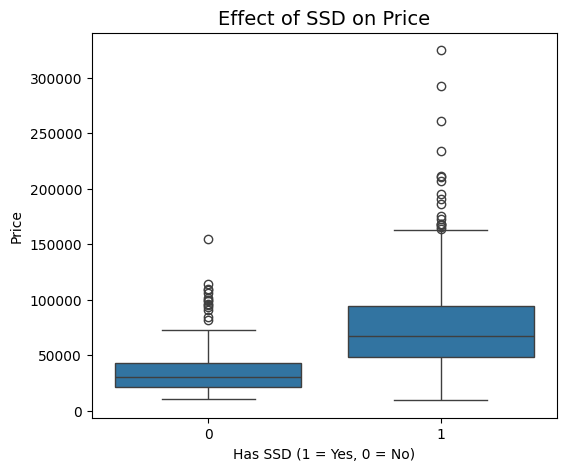

In [47]:
# =====================================
# 🔍 5️⃣ تأثير وجود SSD على السعر
# =====================================
df['Has_SSD'] = df['SSD'].apply(lambda x: 1 if x > 0 else 0)

plt.figure(figsize=(6,5))
sns.boxplot(x='Has_SSD', y='Price', data=df)
plt.title("Effect of SSD on Price", fontsize=14)
plt.xlabel("Has SSD (1 = Yes, 0 = No)")
plt.show()

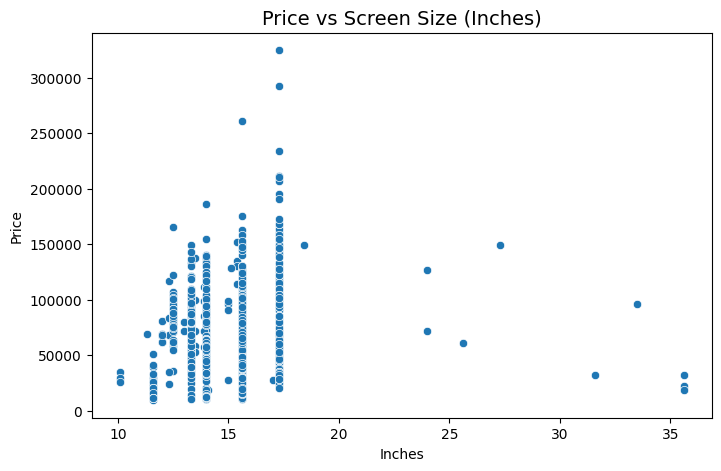

In [48]:
# =====================================
# 🔍 6️⃣ علاقة السعر بالـ Inches
# =====================================
plt.figure(figsize=(8,5))
sns.scatterplot(x='Inches', y='Price', data=df)
plt.title("Price vs Screen Size (Inches)", fontsize=14)
plt.show()

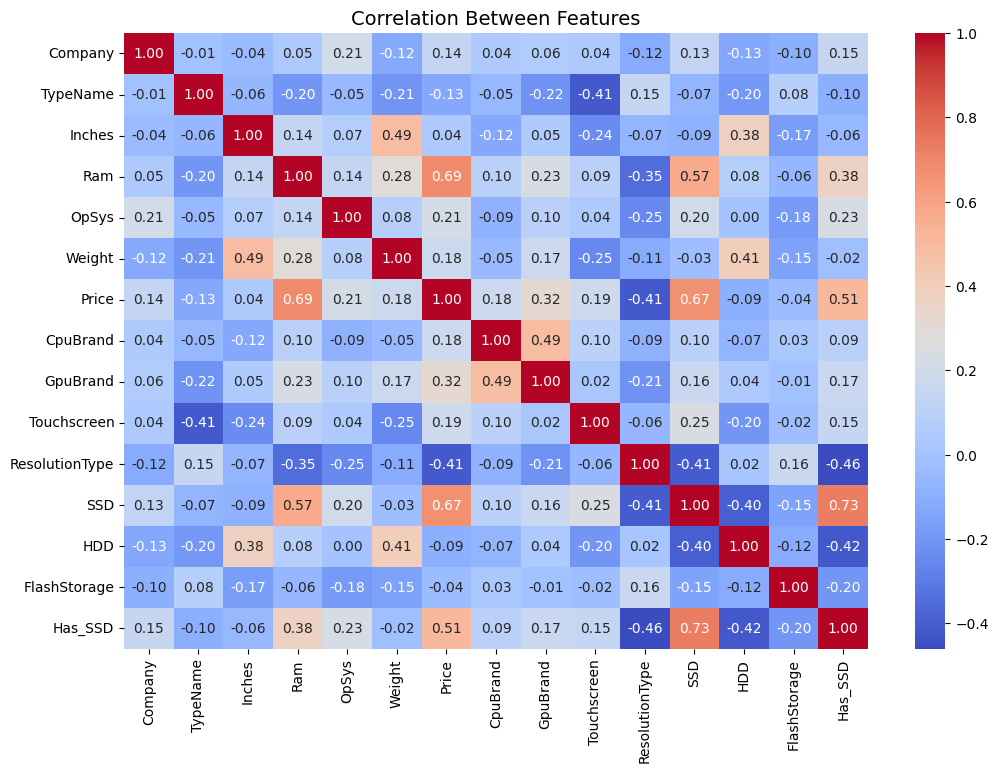

In [49]:
# =====================================
# 🔍 7️⃣ العلاقة بين كل الأعمدة الرقمية (Correlation Matrix)
# =====================================
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Features", fontsize=14)
plt.show()